## The "Value-for-Money" Transfer Scout


*Group 7: Megann Kouandjeu, Salma Kamoun, Axel Chartier*

Instead of just predicting who wins a match, build a model that identifies "Undervalued Players."

**The Problem:** Professional clubs (especially mid-tier ones) have limited budgets. They cannot afford superstars but need top-tier performance to stay competitive or earn promotion.

**The ML Solution:** Create a "Fair Market Value" predictor. By identifying players whose Actual Performance suggests a higher value than their Current Market Price, we provide a "Buy Low" list for the scouting department.

**The ML Task:** Regression (Predicting a player's "Fair Market Value" based on stats). If the model predicts $20M but his real price is $5M, he’s a "Buy."

*Value Proposition: Reducing the financial risk of transfers and finding "gems" in lower leagues that bigger clubs have overlooked.*



### Dataset and Feature Description
For this PoC, we are utilizing a Transfermarkt datalake (https://github.com/salimt/football-datasets). Per project scope, the data will initially be filtered to records from **2024 onwards** to predict current market realities, with the possibility of adding more historical data later to track valuation growth.

| Feature Name | Source File | Type | Description |
| :--- | :--- | :--- | :--- |
| **`value` (TARGET)** | `player_market_value.csv` | Continuous | The current market valuation of the player in Euros. |
| **`age`** | Derived from `player_profiles` | Numerical | Calculated from `date_of_birth` to the present year. |
| **`height`** | `player_profiles.csv` | Numerical | Player height in cm. |
| **`position`** | `player_profiles.csv` | Categorical | The tactical role (e.g., Attack, Defender). |
| **`minutes_played`** | `player_performances.txt` | Numerical | Total time on pitch during the 23/24 and 24/25 seasons. |
| **`goals` & `assists`** | `player_performances.txt` | Numerical | Offensive output metrics. |
| **`days_missed`** | `player_injuries.csv` | Numerical | Total days unavailable due to injury (Risk metric). |

In [1]:
# Loading necessary libraries 

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

### Data loading 

In [2]:
# Loading datasets
df_profiles = pd.read_csv('../datasets/player_profiles.csv')
df_values = pd.read_csv('../datasets/player_market_value.csv')
df_injuries = pd.read_csv('../datasets/player_injuries.csv')
df_performances = pd.read_csv('../datasets/player_performances.txt', sep=',')

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [3]:
df_profiles.head()

,player_id,player_slug,player_name,player_image_url,name_in_home_country,date_of_birth,place_of_birth,country_of_birth,height,citizenship,...,on_loan_from_club_id,on_loan_from_club_name,contract_there_expires,second_club_url,second_club_name,third_club_url,third_club_name,fourth_club_url,fourth_club_name,date_of_death
0,1,silvio-adzic,Silvio Adzic (1),https://img.a.transfermarkt.technology/portrai...,NaN,1980-09-23,Grünstadt,Germany,0.0,Germany,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,100011,everton-silva,Éverton Silva (100011),https://img.a.transfermarkt.technology/portrai...,Éverton José Modesto da Silva,1988-08-04,São João de Meriti,Brazil,171.0,Brazil,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,10,miroslav-klose,Miroslav Klose (10),https://img.a.transfermarkt.technology/portrai...,Miroslav Josef Klose,1978-06-09,Opole,Germany,184.0,Germany,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,10001,john-thompson,John Thompson (10001),https://img.a.transfermarkt.technology/portrai...,John Paul Thompson,1981-10-12,Dublin,Ireland,183.0,Ireland,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,100001,carlos-auzqui,Carlos Auzqui (100001),https://img.a.transfermarkt.technology/portrai...,Carlos Daniel Auzqui,1991-03-16,Longchamps,Argentina,180.0,Argentina,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df_profiles.describe()   

,player_id,height,current_club_id,player_agent_id,on_loan_from_club_id
count,9.267100e+04,92667.000000,92671.000000,38057.000000,3758.000000
mean,4.822020e+05,144.619908,17268.764835,5654.314160,14245.704364
std,3.894922e+05,73.368611,28780.506345,4038.521566,23763.128575
min,1.000000e+00,0.000000,1.000000,1.000000,2.000000
25%,1.214005e+05,171.000000,123.000000,2325.000000,738.000000
50%,4.021140e+05,180.000000,1533.000000,4906.000000,3901.000000
75%,7.989040e+05,185.000000,22177.000000,8598.000000,14926.000000
max,1.459023e+06,210.000000,134553.000000,15015.000000,132806.000000


In [5]:
df_values.head()    

,player_id,date_unix,value
0,1000135,2023-12-19,100000.0
1,1000135,2024-06-23,100000.0
2,10,2005-01-06,9000000.0
3,10,2008-06-03,20000000.0
4,10,2009-08-29,12000000.0


In [6]:
df_values.describe()    

,player_id,value
count,9.014290e+05,9.014290e+05
mean,2.775569e+05,1.544903e+06
std,2.551537e+05,5.424065e+06
min,1.000000e+00,0.000000e+00
25%,6.706300e+04,1.000000e+05
50%,1.996330e+05,3.000000e+05
75%,4.115040e+05,8.000000e+05
max,1.407924e+06,2.000000e+08


In [7]:
df_injuries.head()

,player_id,season_name,injury_reason,from_date,end_date,days_missed,games_missed
0,10,15/16,Hand injury,2016-04-19,2016-04-29,11.0,2
1,10,15/16,Thigh problems,2015-12-18,2015-12-31,14.0,1
2,10,15/16,Capsular injury,2015-11-11,2015-11-21,11.0,0
3,10,15/16,Rest,2015-11-04,2015-11-06,3.0,1
4,10,15/16,Hamstring injury,2015-08-20,2015-10-08,50.0,10


In [8]:
df_injuries.describe()

,player_id,days_missed,games_missed
count,1.431950e+05,143173.000000,143195.000000
mean,2.531593e+05,51.719291,6.628479
std,2.318766e+05,104.437179,9.468380
min,2.000000e+00,1.000000,0.000000
25%,6.168200e+04,10.000000,1.000000
50%,1.888540e+05,22.000000,3.000000
75%,3.817940e+05,53.000000,7.000000
max,1.396965e+06,8655.000000,208.000000


In [9]:
df_performances.head()

,player_id,season_name,competition_id,competition_name,team_id,team_name,nb_in_group,nb_on_pitch,goals,assists,own_goals,subed_in,subed_out,yellow_cards,second_yellow_cards,direct_red_cards,penalty_goals,minutes_played,goals_conceded,clean_sheets
0,1,08/09,OBLG,NOFV-Oberliga Süd,4825,FC Eilenburg,9,9,0.0,0,0,0,2,0,0,1,0,NaN,0,0
1,1,07/08,RS,Regionalliga Süd,1526,FSV Ludwigshafen Oggersheim,22,22,1.0,0,0,3,8,1,0,0,0,1580.0,0,0
2,1,06/07,L2,2. Bundesliga,996,TuS Koblenz,10,4,0.0,0,0,4,0,0,0,0,0,NaN,0,0
3,1,06/07,DFB,DFB-Pokal,996,TuS Koblenz,1,0,0.0,0,0,0,0,0,0,0,0,NaN,0,0
4,1,05/06,L2,2. Bundesliga,66,SpVgg Unterhaching,26,14,1.0,1,0,12,1,1,0,0,0,388.0,0,0


In [10]:
df_performances.describe()

,player_id,team_id,nb_in_group,nb_on_pitch,goals,assists,own_goals,subed_in,subed_out,yellow_cards,second_yellow_cards,direct_red_cards,penalty_goals,minutes_played,goals_conceded,clean_sheets
count,1.878719e+06,1.878719e+06,1.878719e+06,1.878719e+06,1.740517e+06,1.878719e+06,1.878719e+06,1.878719e+06,1.878719e+06,1.878719e+06,1.878719e+06,1.878719e+06,1.878719e+06,708161.000000,1.878719e+06,1.878719e+06
mean,2.916295e+05,1.069298e+04,9.929085e+00,8.156783e+00,9.527192e-01,4.469455e-01,1.532853e-02,1.673163e+00,1.855993e+00,1.111522e+00,3.394068e-02,3.513724e-02,7.551528e-02,606.181230,8.014999e-01,1.911073e-01
std,2.922079e+05,1.770314e+04,1.084346e+01,9.865284e+00,2.283932e+00,1.247370e+00,1.300537e-01,3.035122e+00,3.260543e+00,1.919704e+00,1.930695e-01,1.945535e-01,4.414087e-01,681.591337,4.606050e+00,1.204661e+00
min,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000,-1.000000e+00,0.000000e+00
25%,5.549400e+04,7.980000e+02,2.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,178.000000,0.000000e+00,0.000000e+00
50%,1.894820e+05,3.060000e+03,4.000000e+00,3.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,337.000000,0.000000e+00,0.000000e+00
75%,4.477680e+05,1.144900e+04,1.600000e+01,1.300000e+01,1.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00,2.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,758.000000,0.000000e+00,0.000000e+00
max,1.453181e+06,1.345500e+05,5.100000e+01,5.100000e+01,5.000000e+01,2.900000e+01,9.000000e+00,3.800000e+01,4.000000e+01,2.100000e+01,5.000000e+00,4.000000e+00,1.400000e+01,4590.000000,1.110000e+02,2.900000e+01


### Are there missing values?
Yes, initially there were significant missing values which we handled as such:
* **Performances:** Over 1 million missing values in `minutes_played`, `goals`, and `assists`. We imputed them with `0`, as missingness in football data typically indicates the player did not feature in the match.
* **Profiles:** 23,488 missing values in preferred `foot` were imputed with the category "Unknown". A small number of players missing a `date_of_birth` (1,006) were dropped, as age is a critical feature.
* **Injuries:** 22 records missing `days_missed` were dropped.

In [11]:
# Check for missing values in the columns we actually care about
print("--- MISSING VALUES ---")

print("\n1. Profiles (Static Data):")

# We only check the columns we plan to use
cols_profiles = ['player_id', 'date_of_birth', 'height', 'position', 'foot']

# Use a try-except block just in case some columns have slightly different names
try:
    print(df_profiles[cols_profiles].isnull().sum())
except KeyError as e:
    print(f"Wait, missing a column in Profiles: {e}")

print("\n2. Market Values (Target Data):")
print(df_values[['player_id', 'date_unix', 'value']].isnull().sum())

print("\n3. Performances (Dynamic Data):")
cols_perf = ['player_id', 'season_name', 'minutes_played', 'goals', 'assists']
try:
    print(df_performances[cols_perf].isnull().sum())
except KeyError as e:
    print(f"Wait, missing a column in Performances: {e}")

print("\n4. Injuries (Risk Data):")
cols_inj = ['player_id', 'season_name', 'days_missed']
try:
    print(df_injuries[cols_inj].isnull().sum())
except KeyError as e:
    print(f"Wait, missing a column in Injuries: {e}")

--- MISSING VALUES ---

1. Profiles (Static Data):
player_id            0
date_of_birth     1006
height               4
position             2
foot             23488
dtype: int64

2. Market Values (Target Data):
player_id    0
date_unix    0
value        0
dtype: int64

3. Performances (Dynamic Data):
player_id               0
season_name             0
minutes_played    1170558
goals              138202
assists                 0
dtype: int64

4. Injuries (Risk Data):
player_id       0
season_name     0
days_missed    22
dtype: int64


In [12]:
# Clean and Filter Performances 
# Fill missing minutes and goals with 0
df_performances['minutes_played'] = df_performances['minutes_played'].fillna(0)
df_performances['goals'] = df_performances['goals'].fillna(0)
df_performances['assists'] = df_performances['assists'].fillna(0)

In [13]:
# Keep only the recent seasons (2023/2024 and 2024/2025)
recent_seasons = ['23/24', '24/25']
df_perf_recent = df_performances[df_performances['season_name'].isin(recent_seasons)]

In [14]:
# Clean and Filter Market Values 
# Convert the date string to actual datetime objects
df_values['date_unix'] = pd.to_datetime(df_values['date_unix'])

# Filter for year 2024 onwards
df_values_recent = df_values[df_values['date_unix'].dt.year >= 2024]

# A player might have multiple valuations in 2024. We only want their LATEST one.
df_values_latest = df_values_recent.sort_values('date_unix').drop_duplicates(subset=['player_id'], keep='last')
df_values_latest = df_values_latest.rename(columns={'value': 'market_value_eur'})

In [15]:
# Clean and Filter Injuries 
# Drop the tiny 22 rows missing days_missed
df_injuries = df_injuries.dropna(subset=['days_missed'])

# Keep only recent seasons
df_injuries_recent = df_injuries[df_injuries['season_name'].isin(recent_seasons)]

In [16]:
# Clean Profiles 
# Fill missing foot with 'Unknown'
df_profiles['foot'] = df_profiles['foot'].fillna('Unknown')

# Drop rows without a Date of Birth (we need it for Age!)
df_profiles = df_profiles.dropna(subset=['date_of_birth'])

In [17]:
print("\n--- NEW DATASET SIZES ---")
print(f"Recent Performances: {len(df_perf_recent)} rows")
print(f"2024 Market Values: {len(df_values_latest)} unique players")
print(f"Recent Injuries: {len(df_injuries_recent)} rows")
print(f"Clean Profiles: {len(df_profiles)} players")


--- NEW DATASET SIZES ---
Recent Performances: 209229 rows
2024 Market Values: 41823 unique players
Recent Injuries: 29578 rows
Clean Profiles: 91665 players



### Temporal features -- what range and resolution?
* **Range:** We filtered the data to recent temporal bounds: player valuations from **2024 onwards**, and performance/injury statistics specifically from the **2023/2024 and 2024/2025 seasons**.
* **Resolution:** The original performance and injury data had a "per-match" and "per-injury" resolution. We aggregated this to a **seasonal/yearly resolution** (total minutes, total goals, total days missed per player) to align with their single latest market valuation in 2024. `date_of_birth` was also converted into a static `age` feature based on the year 2024.

### NOW LET'S AGGREGATE AND MERGE OUR DATA

In [18]:
print("--- AGGREGATING DATA ---")

# 1. Aggregate Performances (Sum goals, assists, and minutes per player)
df_perf_agg = df_perf_recent.groupby('player_id')[['minutes_played', 'goals', 'assists']].sum().reset_index()

# 2. Aggregate Injuries (Sum total days missed per player)
df_inj_agg = df_injuries_recent.groupby('player_id')['days_missed'].sum().reset_index()

# 3. Calculate Age in Profiles (Using 2024 as the baseline year)
df_profiles['date_of_birth'] = pd.to_datetime(df_profiles['date_of_birth'])
df_profiles['age'] = 2024 - df_profiles['date_of_birth'].dt.year

--- AGGREGATING DATA ---


In [19]:
# --- MERGING INTO ONE MASTER DATASET ---

# We start with our Target Variable. We ONLY want players who have a known market value.
df_master = df_values_latest[['player_id', 'market_value_eur']]

# Add Profile Info (Age, Height, Position, Foot)
cols_to_keep = ['player_id', 'age', 'height', 'position', 'foot']
df_master = pd.merge(df_master, df_profiles[cols_to_keep], on='player_id', how='inner')

# Add Performance Info (Left join: if they have no stats, they get 0s)
df_master = pd.merge(df_master, df_perf_agg, on='player_id', how='left')
df_master['minutes_played'] = df_master['minutes_played'].fillna(0)
df_master['goals'] = df_master['goals'].fillna(0)
df_master['assists'] = df_master['assists'].fillna(0)

# Add Injury Info (Left join: if they aren't in the injury file, they missed 0 days)
df_master = pd.merge(df_master, df_inj_agg, on='player_id', how='left')
df_master['days_missed'] = df_master['days_missed'].fillna(0)

print("\n--- FINAL MASTER DATASET ---")
print(f"Total Players ready for Machine Learning: {len(df_master)}")
print(df_master.head()) # Shows the first 5 rows to verify it worked!


--- FINAL MASTER DATASET ---
Total Players ready for Machine Learning: 41772
   player_id  market_value_eur  age  height                       position  \
0    1023555               0.0   20   188.0         Defender - Centre-Back   
1      58576               0.0   36   180.0          Defender - Right-Back   
2      74295               0.0   33   175.0  Midfield - Defensive Midfield   
3      92056               0.0   35   186.0         Defender - Centre-Back   
4      59551               0.0   36   180.0    Midfield - Central Midfield   

      foot  minutes_played  goals  assists  days_missed  
0  Unknown             0.0    0.0      0.0          0.0  
1    right             0.0    0.0      1.0          0.0  
2    right             0.0    0.0      0.0          0.0  
3    right             0.0    0.0      0.0          0.0  
4    right             0.0    0.0      0.0          0.0  


In [20]:
print("--- REMOVING INACTIVE PLAYERS ---")

# Keep only players who have an actual market value AND actually stepped on the pitch
df_master_clean = df_master[(df_master['market_value_eur'] > 0) & (df_master['minutes_played'] > 0)]

print(f"Total Active Players for ML: {len(df_master_clean)}")
print(df_master_clean.sample(5)) 

--- REMOVING INACTIVE PLAYERS ---
Total Active Players for ML: 23459
       player_id  market_value_eur  age  height                     position  \
22987     504147         2000000.0   22   170.0         Defender - Left-Back   
35666    1099061          300000.0   19   188.0                   Goalkeeper   
28440     562049         5000000.0   22   181.0  Midfield - Central Midfield   
41325     288786         2000000.0   30   186.0      Attack - Centre-Forward   
32680      89034          200000.0   33   190.0       Defender - Centre-Back   

        foot  minutes_played  goals  assists  days_missed  
22987   left          2863.0    2.0      4.0          5.0  
35666  right          4590.0    0.0      1.0          0.0  
28440  right          1564.0    2.0      6.0        298.0  
41325  right           133.0    6.0      0.0        334.0  
32680  right           748.0    4.0      1.0         22.0  


### Exploratory Data Analysis (EDA) Findings

As part of the initial data exploration, we generated three visualizations to understand the distribution of our target variable (`market_value_eur`) and its relationship with our chosen features.

#### 1. Distribution of Market Values (Log Scale)
* **Observation:** The histogram shows a massive right-skew (which is why a logarithmic scale was necessary to visualize it properly). 
* **Insight:** The vast majority of professional players have relatively low market values (under €1M - €5M), while a very small percentage of "superstars" hold valuations exceeding €50M to €100M+. 
* **Modeling Implication:** Because the target variable is highly skewed, we will likely need to apply a log transformation to the market value during the machine learning phase so the model doesn't over-index on predicting just the billionaires.

#### 2. Age vs. Market Value (The Aging Curve)
* **Observation:** The scatter plot perfectly captures the classic "football aging curve." 
* **Insight:** Players at age 17-19 start with lower baseline values. Valuations peak significantly between the ages of 22 and 28, representing a player's physical and professional prime. After age 30, market values steadily decline regardless of the player's underlying skill.
* **Modeling Implication:** The relationship between age and market value is **non-linear** (it looks like a hill, not a straight line). We may need to use models that handle non-linear relationships well (like Random Forests or Gradient Boosting).

#### 3. Feature Correlation Heatmap
*Note: A correlation matrix only measures **linear** relationships (straight lines). If a relationship is curved (like age), the correlation score will appear artificially low.*

* **Offensive Output Drives Value:** `assists` (0.29) and `goals` (0.24) have the highest positive correlation with market value. This aligns with football reality: attacking players who produce direct goal contributions command the highest transfer fees.
* **The "Age" Illusion:** `age` shows a near-zero correlation (-0.05). This is not because age doesn't matter, but because the relationship is an inverted U-shape (as proven by our scatter plot). Since the matrix looks for a straight line, the early rise and later fall cancel each other out to near zero.
* **Feature Interaction:** `goals` and `assists` are strongly correlated with each other (0.54). This makes sense, as highly involved attacking players tend to produce both. 
* **Playing Time:** `minutes_played` has a surprisingly low correlation with value (0.06). This indicates that simply being on the pitch isn't enough to make a player valuable; it's *what they do* during those minutes and their specific position that dictates their price.

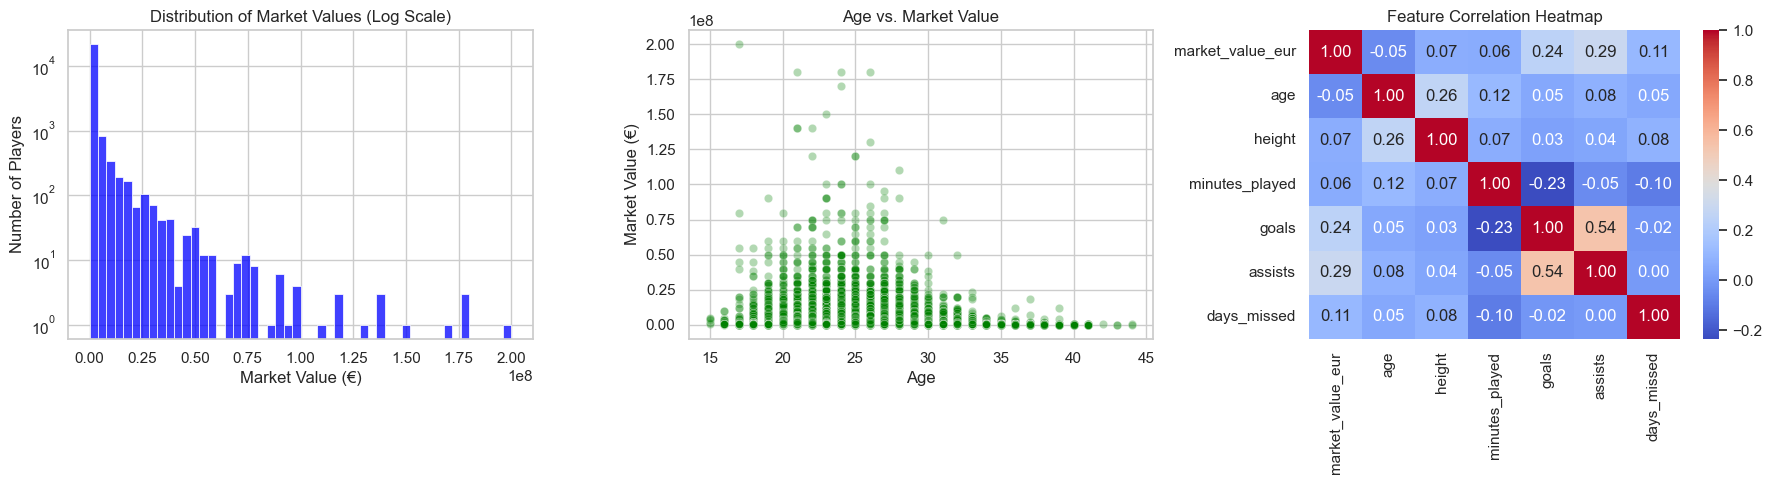

In [21]:
# Setting the style for pretty charts
sns.set_theme(style="whitegrid")

# Create a figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Chart 1: Distribution of Market Value ---
# We use a log scale because Mbappe is worth €180M while most are worth €500k
sns.histplot(df_master_clean['market_value_eur'], bins=50, ax=axes[0], color='blue')
axes[0].set_yscale('log') 
axes[0].set_title('Distribution of Market Values (Log Scale)')
axes[0].set_xlabel('Market Value (€)')
axes[0].set_ylabel('Number of Players')

# --- Chart 2: Age vs Market Value ---
sns.scatterplot(data=df_master_clean, x='age', y='market_value_eur', alpha=0.3, ax=axes[1], color='green')
axes[1].set_title('Age vs. Market Value')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Market Value (€)')

# --- Chart 3: Correlation Heatmap ---
# We select only the numerical columns to see how they correlate with each other
numeric_cols = ['market_value_eur', 'age', 'height', 'minutes_played', 'goals', 'assists', 'days_missed']
corr_matrix = df_master_clean[numeric_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[2])
axes[2].set_title('Feature Correlation Heatmap')

plt.tight_layout()
plt.show()

### Saving training data to a new csv file

In [22]:
print("--- SAVING MASTER DATASET ---")

# We will save it right next to your other datasets using your absolute path
save_path = r'..\datasets\master_training_data.csv'

# index=False prevents pandas from saving those random row numbers (26341, 13311, etc.)
df_master_clean.to_csv(save_path, index=False)

print(f"Success! Clean data saved to: {save_path}")
print("You are now fully ready for Machine Learning.")

--- SAVING MASTER DATASET ---
Success! Clean data saved to: ..\datasets\master_training_data.csv
You are now fully ready for Machine Learning.


### Is the dataset balanced?
No, the dataset contains expected real-world imbalances across both continuous and categorical features:
* **Target Variable (`market_value_eur`):** The target is extremely imbalanced (right-skewed). Mathematical proof of this is a **skewness score of 10.32** (anything > 1 is highly skewed). The "average" player is pulled up by a few superstar outliers (Mean = €1.95M), while the "typical" player is valued much lower (Median = €300k).
* **Categorical Features (Foot):** Foot preference is naturally imbalanced, reflecting real-world human demographics. Right-footed players dominate at **66.2%**, followed by left-footed (22.7%), unknown (7.2%), and both/ambidextrous (3.9%). 
* **Categorical Features (Position):** Players are spread across 16 positional labels, but heavily concentrated in the core roles. The top four positions (Centre-Forward, Centre-Back, Central Midfield, Goalkeeper) make up roughly **55%** of the dataset. Conversely, there are generic labels (`Attack`, `Midfield`, `Defender`) that make up less than 0.1% of the data, which may require grouping or cleaning during the modeling phase.

In [23]:
print("--- DATASET BALANCE CHECK ---")

# 1. Target Variable Balance (Market Value)
print("\n1. Target Variable (Market Value):")
skewness = df_master_clean['market_value_eur'].skew()
print(f"Skewness Score: {skewness:.2f} (Anything > 1 is highly skewed)")

mean_val = df_master_clean['market_value_eur'].mean()
median_val = df_master_clean['market_value_eur'].median()
print(f"Mean Value:   €{mean_val:,.0f}")
print(f"Median Value: €{median_val:,.0f}")
print("Conclusion: Extremely imbalanced. The 'average' is pulled way up by a few superstars, while the 'typical' (median) player is much cheaper.")

# 2. Categorical Balance (Position)
print("\n2. Class Balance for 'Position' (Percentages):")
# value_counts(normalize=True) calculates the exact percentage breakdown!
position_pct = round(df_master_clean['position'].value_counts(normalize=True) * 100, 1)
print(position_pct.astype(str) + '%')

# 3. Categorical Balance (Foot)
print("\n3. Class Balance for 'Foot' (Percentages):")
foot_pct = round(df_master_clean['foot'].value_counts(normalize=True) * 100, 1)
print(foot_pct.astype(str) + '%')

--- DATASET BALANCE CHECK ---

1. Target Variable (Market Value):
Skewness Score: 10.32 (Anything > 1 is highly skewed)
Mean Value:   €1,948,980
Median Value: €300,000
Conclusion: Extremely imbalanced. The 'average' is pulled way up by a few superstars, while the 'typical' (median) player is much cheaper.

2. Class Balance for 'Position' (Percentages):
position
Attack - Centre-Forward          15.8%
Defender - Centre-Back           15.5%
Midfield - Central Midfield      12.5%
Goalkeeper                       11.7%
Attack - Left Winger              8.0%
Midfield - Attacking Midfield     7.6%
Attack - Right Winger             7.4%
Midfield - Defensive Midfield     6.7%
Defender - Right-Back             5.8%
Defender - Left-Back              5.6%
Midfield - Right Midfield         1.3%
Midfield - Left Midfield          1.1%
Attack - Second Striker           0.9%
Attack                            0.1%
Midfield                          0.0%
Defender                          0.0%
Name: propor

### Other Dataset Characteristics & Initial Observations

#### Do we have categorical features? How many classes each?
Yes, we have two primary categorical features:
* **`position`:** Represents the player's primary role on the pitch (e.g., Attack - Centre-Forward, Midfield - Defensive Midfield). There are approximately **13 to 15 unique classes** depending on the specific tactical breakdowns in the dataset.
* **`foot`:** Represents the player's preferred kicking foot. It contains **4 classes**: `right`, `left`, `both`, and `Unknown`.

#### Do we have continuous features? What range and distribution?
Yes, our dataset relies heavily on continuous features. 
* **`market_value_eur` (Target):** Ranges from ~€10,000 to €180,000,000+. Follows a strict exponential/logarithmic distribution.
* **`age`:** Ranges from roughly 15 to 40+ years old. Follows a normal distribution centered around 24-26 years old.
* **`height`:** Ranges from roughly 160cm to 200cm+. Follows a tight normal distribution.
* **`minutes_played`:** Ranges from 1 to 4000+ minutes. 
* **`goals` & `assists`:** Ranges from 0 to 15+ (in our sample). Strongly right-skewed, as most players (especially defenders and goalkeepers) score 0 goals.
* **`days_missed` (Injuries):** Ranges from 0 to hundreds of days. Heavily right-skewed, as the majority of players have 0 days missed.

### Project Strategy & Machine Learning Context

**1. Business Objective**
The primary business problem we are addressing is the subjective and often inflated nature of the football transfer market. Clubs, sporting directors, and scouting agencies need an objective baseline to evaluate a player's worth. By predicting a player's `market_value_eur` using purely data-driven metrics (performance, age, physical traits, and injury risk), clubs can:
* Identify undervalued talent for smart acquisitions.
* Avoid overpaying for players whose statistical output does not justify their price tag.
* Conduct data-backed contract negotiations.

**2. Machine Learning Context**
From a Machine Learning perspective, this is a **Supervised Learning** problem because we have a labeled target variable (`market_value_eur`) that we want the model to learn to predict. Specifically, this is a **Regression** task, as the target is a continuous numerical value (currency) rather than a category or class.

**3. Cost Function & Evaluation Metrics**
Because our target variable is incredibly right-skewed (spanning from €10,000 to over €100,000,000), standard evaluation metrics can be misleading if used blindly. We will evaluate our pipeline using:
* **MAE (Mean Absolute Error):** To give us a highly interpretable baseline (e.g., "On average, our model's predictions are off by €X").
* **RMSLE (Root Mean Squared Logarithmic Error):** This is critical for our skewed data. Being wrong by €2 million on a €3 million player is a massive error, but being wrong by €2 million on Kylian Mbappé (€180M) is an excellent prediction. RMSLE penalizes percentage errors rather than absolute scale errors.
* **R-squared (R²):** To measure the proportion of the variance in market value that is predictably explained by our selected features.
* **Business Metric (ROI):** We can calculate the "Valuation Gap". If the model identifies a player worth €10M who is currently selling for €2M, the potential "Return on Investment" will be €8M.

**4. Main Risks, Assumptions, and Expected Limitations**
* **Limitation - Missing Positional Nuance:** Our dataset primarily tracks goals and assists. This means attacking players will have strong predictive signals, but we lack defensive stats (interceptions, tackles) and goalkeeping stats (clean sheets, save percentage). The model may systematically undervalue elite defenders and goalkeepers.
* **Limitation - Intangibles:** Market value is heavily influenced by "intangibles" not present in our data, such as a player's commercial/brand value (shirt sales), leadership traits, or contract length remaining.
* **Risk - Extreme Outliers:** Because the top 1% of players hold valuations completely detached from the rest of the pack, the model may struggle to accurately predict the exact prices of the world's most expensive superstars.
* **Assumption:** For now on we are assuming that a player's statistical output from the 2023-2025 seasons is the primary driver of their latest 2024 valuation.